# **Red de Colas**

Este Notebook Jupyter implementa una red de colas de un Centro de Diagnóstico Automotriz que emiten la revisión técnico-mecánica de acuerdo con la descripción de: [<a href="https://drive.google.com/file/d/0B0MRo23s_UhySlJVYU41QlBkaWs/view?usp=sharing">Sec. 5.5.2 Rios08 </a> ], y la siguiente figura.

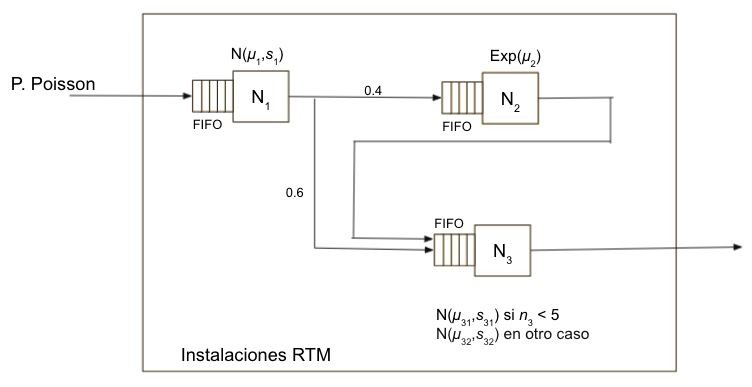

In [8]:
%matplotlib inline

import numpy as np
import math
import random
import matplotlib.pyplot as plt

In [9]:
L = 2.0
mu1 = 2.1
sigma1 = 0.5
mu2 = 2.4
mu31 = 3.1
sigma31 = 2.5
mu32 = 2.0
sigma32 = 2.0

def Llegada_cliente(tsuc):
    global t, n_med_n1, n1, NLL1, LL1, TSuc, mu1, sigma1, LLt

    n_med_n1 = n_med_n1 + n1*(tsuc-t)
    n1 = n1 + 1

    LLt.append(tsuc)

    NLL1 = NLL1 + 1
    LL1.append(tsuc)
    t=tsuc

    Y = np.random.exponential(L)

    if (t+Y) < T:
        TSuc['tLL1'] = t + Y
    if n1 == 1:
        Y = np.random.normal(mu1, sigma1)
        if Y < 0:
            Y = 0
        TSuc['tS1'] = t + Y

def Servicio_nodo1(tsuc):
    global t, n1, n2, n3, n_med_n1, n_med_n2, n_med_n3, NS1, S1, NLL2, NLL3, LL2, LL3, TSuc, mu31, sigma31, mu2, mu1, sigma1
    n_med_n1 = n_med_n1 + n1*(tsuc - t)
    n1 = n1 - 1

    NS1 = NS1 + 1
    S1.append(tsuc)
    U = np.random.uniform(0,1)
    if U <= 0.4:
        n_med_n2 = n_med_n2 + n2*(tsuc-t)
        n2 = n2 + 1

        NLL2 = NLL2 + 1
        LL2.append(tsuc)
        if n2 == 1:
            Z = np.random.exponential(mu2)
            TSuc['tS2'] = tsuc + Z
    else:
        n_med_n3 = n_med_n3 + n3*(tsuc - t)
        n3 = n3 + 1

        NLL3 = NLL3 + 1
        LL3.append(tsuc)
        if n3 == 1:
            W = np.random.normal(mu31, sigma31)
            if W < 0:
                W = 0
            TSuc['tS3'] = tsuc + W
    t = tsuc
    if n1 > 0:
        S = np.random.normal(mu1, sigma1)
        if S < 0:
            S = 0
        TSuc['tS1'] = tsuc + S

def Servicio_nodo2(tsuc):
    global t, n2, n3, n_med_n2, n_med_n3, NS2, NLL3, LL3, S2, TSuc, mu31, sigma31, mu2
    n_med_n2 = n_med_n2 + n2*(tsuc - t)
    n2 = n2 - 1

    NS2 = NS2 + 1
    S2.append(tsuc)
    if n2 > 0:
        Y = np.random.exponential(mu2)
        TSuc['tS2'] = tsuc + Y
    n_med_n3 = n_med_n3 + n3*(tsuc - t)
    n3 = n3 + 1

    NLL3 = NLL3 + 1
    LL3.append(tsuc)
    if n3 == 1:
        W = np.random.normal(mu31, sigma31)
        if W < 0:
            W = 0
        TSuc['tS3'] = tsuc + W
    t = tsuc

def Servicio_nodo3(tsuc):
    global t, n3, n_med_n3, NS3, S3, TSuc, mu31, sigma31, mu32, sigma32, St
    n_med_n3 = n_med_n3 + n3*(tsuc - t)
    n3 = n3 - 1

    St.append(tsuc)

    NS3 = NS3 + 1
    S3.append(tsuc)
    if n3 > 0:
        if n3 < 5:
            R = np.random.normal(mu31, sigma31)
        else:
            R = np.random.normal(mu32, sigma32)
        if R < 0:
            R = 0
        TSuc['tS3'] = tsuc + R
    t = tsuc

In [10]:
M = 999999.0

#np.random.seed(137)

at = []
LLt = []
St = []
an1 = []
an2 = []
an3 = []
an = []

T = 300.0

t = tsuc = Tp = 0

NLL1 = NLL2 = NLL3 = NS1 = NS2 = NS3 = n1 = n2 = n3 = 0

n_med_n1 = n_med_n2 = n_med_n3 = 0


TSuc = {"tLL1":M, "tS1":M, "tS2":M, "tS3":M}

LL1 = []
LL2 = []
LL3 = []

S1 = []
S2 = []
S3 = []

X = np.random.exponential(L)

if X > T:
    Tp = t_med_sistema = 0.0
    n_med_n1 = n_med_n2 = n_med_n3 = 0
    exit
else:
    Llegada_cliente(X)
    while (min([TSuc['tLL1'],TSuc['tS1'],TSuc['tS2'],TSuc['tS3']])!=M):
        if min([TSuc['tLL1'],TSuc['tS1'],TSuc['tS2'],TSuc['tS3']]) == TSuc['tLL1']:
            tsuc = TSuc['tLL1']
            TSuc['tLL1'] = M
            Llegada_cliente(tsuc)
        if min([TSuc['tLL1'],TSuc['tS1'],TSuc['tS2'],TSuc['tS3']]) == TSuc['tS1']:
            tsuc = TSuc['tS1']
            TSuc['tS1'] = M
            Servicio_nodo1(tsuc)
        if min([TSuc['tLL1'],TSuc['tS1'],TSuc['tS2'],TSuc['tS3']]) == TSuc['tS2']:
            tsuc = TSuc['tS2']
            TSuc['tS2'] = M
            Servicio_nodo2(tsuc)
        if min([TSuc['tLL1'],TSuc['tS1'],TSuc['tS2'],TSuc['tS3']]) == TSuc['tS3']:
            tsuc = TSuc['tS3']
            TSuc['tS3'] = M
            Servicio_nodo3(tsuc)
        at.append(tsuc)
        an1.append(n1)
        an2.append(n2)
        an3.append(n3)
        an.append(n1+n2+n3)

    Tp = max(0,t-T)
    acumulo1 = acumulo2 = acumulo3 = 0.0

    ind = 0
    while ind < NLL1:
        acumulo1 = acumulo1 + S1[ind] - LL1[ind]
        ind = ind + 1
    ind = 0
    while ind < NLL2:
        acumulo2 = acumulo2 + S2[ind] - LL2[ind]
        ind = ind + 1
    ind = 0
    while ind < NLL3:
        acumulo3 = acumulo3 + S3[ind] - LL3[ind]
        ind = ind + 1

    t_med_sistema = (acumulo1/NLL1) + (0.4*acumulo2/NLL2) + (acumulo3/NLL3)

    n_med_n1 = n_med_n1 / t
    n_med_n2 = n_med_n2 / t
    n_med_n3 = n_med_n3 / t

    exit

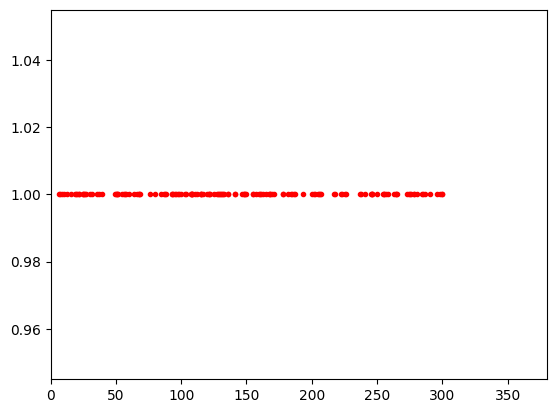

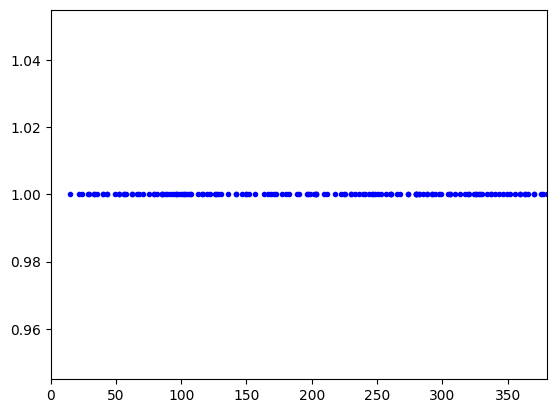

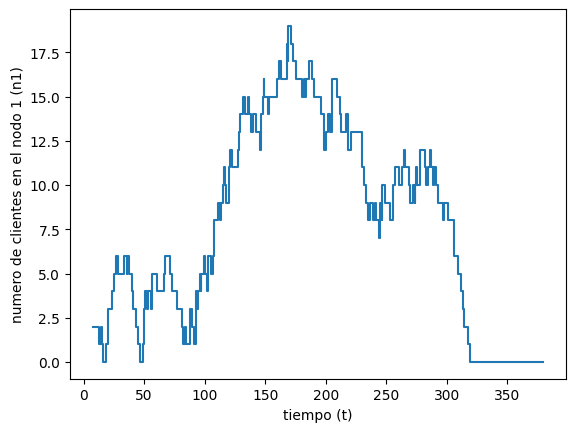

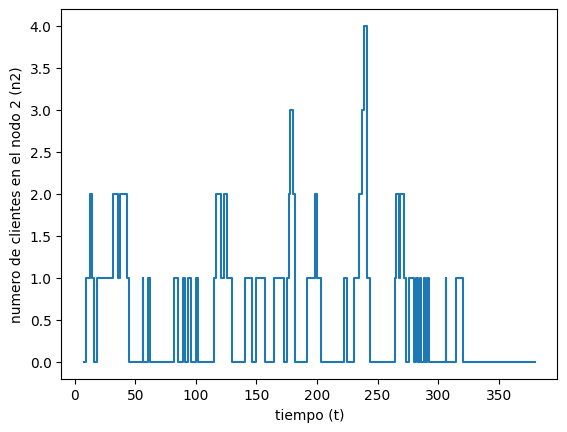

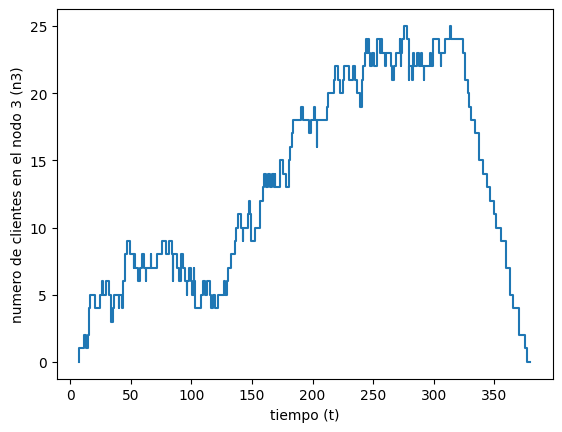

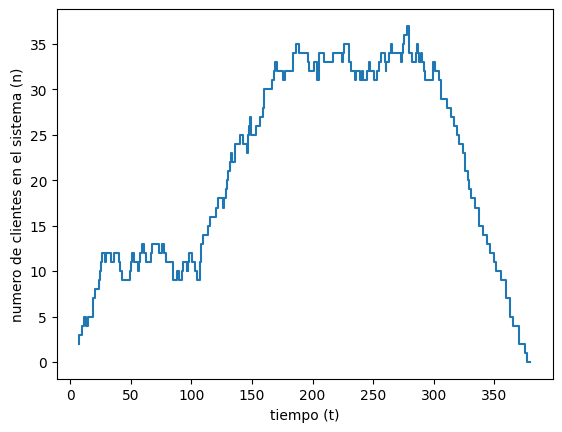

Tiempo medio de los clientes en el sistema (t_med_sistema):  53.6732061739827
Número promedio de clientes en el nodo 1 (n_med_n1):  5.077028942523886
Número promedio de clientes en el nodo 2 (n_med_n2):  0.19489620093005589
Número promedio de clientes en el nodo 3 (n_med_n3):  8.270977203788094
Tiempo transcurrido desde T hasta que el último cliente abandona el sistema:  79.80971601634587
Número máximo de clientes en el sistema:  37
Total de clientes que pasaron por el nodo 1 (n1):  151
Total de clientes que pasaron por el nodo 2 (n2):  64
Total de clientes que pasaron por el nodo 3 (n3):  151
Total de clientes que pasaron por el sistema:  151


In [11]:
at = np.array(at)
an1 = np.array(an1)
an2 = np.array(an2)
an3 = np.array(an3)
an = np.array(an)

LLt = np.array(LLt)
St = np.array(St)

tmp = np.zeros((len(LLt)))+1

plt.plot(LLt, tmp, 'r.')
plt.xlim(0, max(at))
plt.show()

tmp = np.zeros((len(St)))+1

plt.plot(St, tmp, 'b.')
plt.xlim(0, max(at))
plt.show()

plt.step(at,an1)
plt.xlabel('tiempo (t)')
plt.ylabel('numero de clientes en el nodo 1 (n1)')
plt.show()

plt.step(at,an2)
plt.xlabel('tiempo (t)')
plt.ylabel('numero de clientes en el nodo 2 (n2)')
plt.show()

plt.step(at,an3)
plt.xlabel('tiempo (t)')
plt.ylabel('numero de clientes en el nodo 3 (n3)')
plt.show()

plt.step(at,an)
plt.xlabel('tiempo (t)')
plt.ylabel('numero de clientes en el sistema (n)')
plt.show()

print("Tiempo medio de los clientes en el sistema (t_med_sistema): ",t_med_sistema)
print("Número promedio de clientes en el nodo 1 (n_med_n1): ",n_med_n1)
print("Número promedio de clientes en el nodo 2 (n_med_n2): ",n_med_n2)
print("Número promedio de clientes en el nodo 3 (n_med_n3): ",n_med_n3)
print("Tiempo transcurrido desde T hasta que el último cliente abandona el sistema: ",Tp)
print("Número máximo de clientes en el sistema: ",max(an))
print("Total de clientes que pasaron por el nodo 1 (n1): ",NS1)
print("Total de clientes que pasaron por el nodo 2 (n2): ",NS2)
print("Total de clientes que pasaron por el nodo 3 (n3): ",NS3)
print("Total de clientes que pasaron por el sistema: ",NLL3)